In [2]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Names and NetID
# Vedaant Magow - vmagow2
# Dhruv Vohra - dhruvv4
# Brian Keating - brianmk3

In [4]:
# Task 0 part 1
import pandas as pd

# Load the raw dictionary
raw_dict = pd.read_pickle("delta_a100_gpu_xid_dataset.pkl") #equivalent to opening file using "rb" and using the "pickle.load" function

In [5]:
# Task 0 part 2
march_10_2024_errors = raw_dict["2024-03-10"]  # retrive list of all errors on desired date from dictionary

# part 2a
print("Total XID errors on March 10, 2024:", len(march_10_2024_errors)) # len() of this list will give total number of errors on date

# part 2b
# obtain the XID of every error from the date
xids = []
for entry in march_10_2024_errors: 
    xids.append(entry["XID"])
unique_xids = list(set(xids)) # conversion to set removes duplicates, then convert back to list for output
print("Unique XID list:", unique_xids)

Total XID errors on March 10, 2024: 87
Unique XID list: [74, 43, 45, 13, 119, 31]


In [6]:
# Task 0 part 3
# Flatten the dictionary into a single list of all errors
all_errors = []
for date, error_list in raw_dict.items():
   for i in error_list:
      i["Date"] = date
      all_errors.append(i)

# Convert that list into a Pandas DataFrame
df = pd.DataFrame(all_errors)
df = df[["Date", "datetime", "timestamp", "node_name", "device_id","XID","Tag"]] # reorders columns in desired format
df = df.sort_values(by = 'timestamp') # sorts by increasing timestamp
df.head() # view the first few entries 

,Date,datetime,timestamp,node_name,device_id,XID,Tag
0,2022-07-17,2022-07-17T10:27:27.422837-05:00,1.658072e+09,gpua088,0000:c7:00,119,119_GSP_RPC_timeout
1,2022-07-17,2022-07-17T10:29:29.304632-05:00,1.658072e+09,gpua048,0000:07:00,45,045_GPU_PREEMPTIVE_CLEANUP
2,2022-07-17,2022-07-17T11:03:11.093546-05:00,1.658074e+09,gpua001,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
3,2022-07-17,2022-07-17T11:04:15.807907-05:00,1.658074e+09,gpua044,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
4,2022-07-17,2022-07-17T11:10:53.818266-05:00,1.658074e+09,gpua045,0000:07:00,43,043_GPU_STOPPED_PROCESSING


In [7]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [8]:
# Task 1 part 1 
# print the first 10 rows (already in increasing order by timestamp)
df.head(10) 

,Date,datetime,timestamp,node_name,device_id,XID,Tag
0,2022-07-17,2022-07-17T10:27:27.422837-05:00,1.658072e+09,gpua088,0000:c7:00,119,119_GSP_RPC_timeout
1,2022-07-17,2022-07-17T10:29:29.304632-05:00,1.658072e+09,gpua048,0000:07:00,45,045_GPU_PREEMPTIVE_CLEANUP
2,2022-07-17,2022-07-17T11:03:11.093546-05:00,1.658074e+09,gpua001,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
3,2022-07-17,2022-07-17T11:04:15.807907-05:00,1.658074e+09,gpua044,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
4,2022-07-17,2022-07-17T11:10:53.818266-05:00,1.658074e+09,gpua045,0000:07:00,43,043_GPU_STOPPED_PROCESSING
5,2022-07-17,2022-07-17T11:16:30.534940-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
6,2022-07-17,2022-07-17T11:27:40.849346-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
7,2022-07-17,2022-07-17T12:10:20.898006-05:00,1.658078e+09,gpua072,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
8,2022-07-17,2022-07-17T13:21:30.008143-05:00,1.658082e+09,gpua081,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
9,2022-07-17,2022-07-17T13:21:34.279469-05:00,1.658082e+09,gpua005,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION


In [9]:
# Task 1 part 1 cont.
# first timestamp in both unix and human-readable datetime
unix_time = df.iloc[0]["timestamp"]
human_readable = pd.to_datetime(unix_time, unit='s')
print("first time stamp in Unix is ", unix_time)
print("first time stamp in human readable format is ", human_readable)

first time stamp in Unix is  1658071647.4228365
first time stamp in human readable format is  2022-07-17 15:27:27.422836542


In [10]:
# Task 1 part 2a

count_XID_43 = df[df['XID'] == 43] # number of errors with XID = 43
print('errors with XID equals 43:' , len(count_XID_43))

total = len(df) # total rows
print('all rows total:' , total)

# Prob XID 43 = Number of times XID is 43 / Total Amount of Rows of Data
Probability_Task1_Part2a = len(count_XID_43)/total
print('probability that XID = 43 when random sample:', Probability_Task1_Part2a)

errors with XID equals 43: 8592
all rows total: 73514
probability that XID = 43 when random sample: 0.11687569714612182


In [11]:
# Task 1 part 2b

count_XID_119 = df[df['XID'] == 119] # number of errors with XID = 119
print('errors with XID equals 119:' , len(count_XID_119))

print('all rows total:' , total) # total rows

# same probability formula as part 2a
Probability_Task1_Part2b = len(count_XID_119)/total
print('probability that XID = 43 when random sample:', Probability_Task1_Part2b)

errors with XID equals 119: 1303
all rows total: 73514
probability that XID = 43 when random sample: 0.017724515058356233


In [12]:
# task 1 part 2c
# user error is way more likely than hardware error 0.116>0.0177

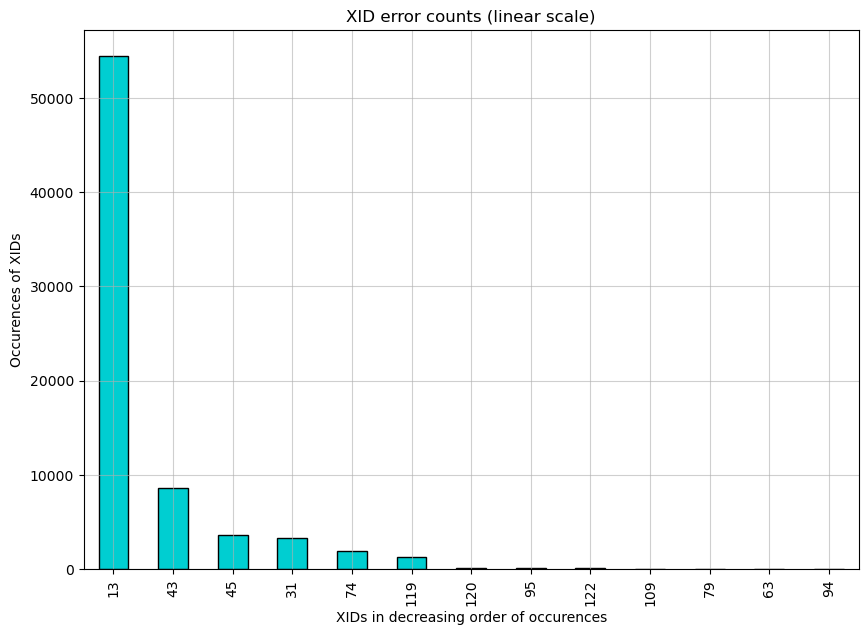

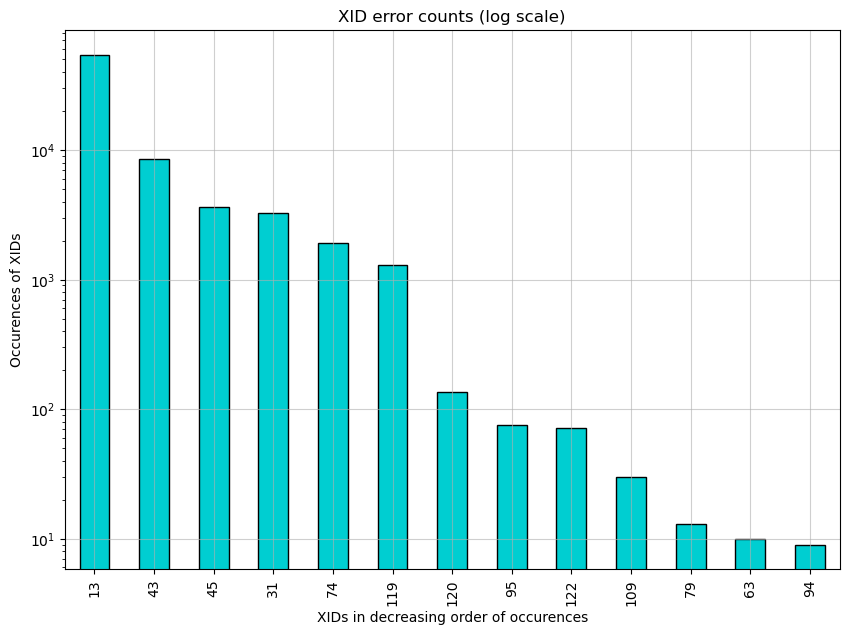

In [13]:
# Task 1 Part 3
import matplotlib.pyplot as plt

# count occurences of each XID to sort and plot
plot_errorXIDs = df['XID'].value_counts()

# plot with linear y-axis scale
plt.figure(figsize=(10,7))
plot_errorXIDs.sort_values(ascending = False).plot(kind = 'bar', color = 'darkturquoise' , edgecolor = 'black' ) 
plt.title("XID error counts (linear scale)")
plt.xlabel('XIDs in decreasing order of occurences')
plt.ylabel('Occurences of XIDs')
plt.grid(axis = 'x', linestyle = '-', alpha = 0.6)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.6)
plt.show()

# plot with log y-axis scale
plt.figure(figsize=(10,7))
plot_errorXIDs.sort_values(ascending = False).plot(kind = 'bar', color = 'darkturquoise' , edgecolor = 'black' ) 
plt.yscale('log') # key change to have log scale
plt.title("XID error counts (log scale)")
plt.xlabel('XIDs in decreasing order of occurences')
plt.ylabel('Occurences of XIDs')
plt.grid(axis = 'x', linestyle = '-', alpha = 0.6)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.6)
plt.show()

In [14]:
# Task 1 part 4a
# Based on the plot the most dominant XID is 13. 

# Task 1 part 4b
# Top 5 XIDs that occurred in the dataset are 13, 43, 45, 31 and 74

# Task 1 part 4c
# According to the study XID 74 is an interconnect error, Description according to study: 
# NVLink error indicating connection issues between GPUs via NVLink interconnection.
# Finding its Tag now
# to find the tag we located it using the XID and .unique() cause there are multiple errors with XID 74 
# unique just makes it easy and returns 1(they have the same tags)
# also .unique() returns an array so [0] is used to access the only element
tag_74 = df.loc[df['XID'] == 74, 'Tag'].unique()[0]
print("tag for XID 74 is ", tag_74)

tag for XID 74 is  074_NVLINK_error


In [15]:
# Task 1 part 5a
# making histogram of timestamps using .diff
# since we have the timestamps we use .diff() on the columns, this calculates the diff between the current and previous row. 
# We exactly need to plot this because each row is a new error and we need the time between each consecutive error

time_intervals = df["timestamp"].diff()
print(time_intervals)

# removing the NaN value that can be seen below.
# This is needed for the other math related functions that are to come.

time_intervals = time_intervals.dropna()

0                NaN
1         121.881796
2        2021.788913
3          64.714361
4         398.010359
            ...     
73509    2046.415668
73510     331.060869
73511     716.815888
73512     329.312100
73513     834.598951
Name: timestamp, Length: 73514, dtype: float64


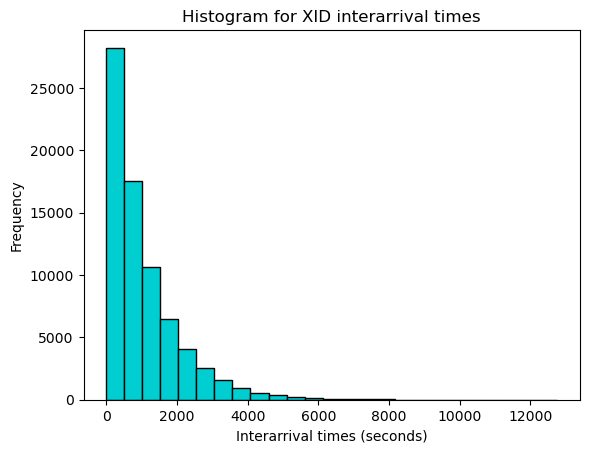

the mean interarrival time in seconds is 1054.4875208708004
the standard deviation in seconds is 1061.6875418103216


In [16]:
# plotting histogram (continuing Task 1 part 5a)
plt.hist(time_intervals, bins = 25, color = 'darkturquoise',edgecolor  = 'black')
plt.title("Histogram for XID interarrival times")
plt.ylabel("Frequency")
plt.xlabel("Interarrival times (seconds)")
plt.show()

# Task 1 part 5b
# easy to calculate mean and standard deviation with inbuilt functions
mean_time = time_intervals.mean()
print("the mean interarrival time in seconds is", mean_time)
time_interval_std = time_intervals.std()
print("the standard deviation in seconds is", time_interval_std)

In [17]:
# Task 1 part 5c
# since the entire system is being used and every XID is critical,
# the average time a user would be able to run their job before being interrupted by an XID is the same as the MEAN = 1054.49 seconds

In [18]:
# for Task 1 part 6 we used the .goodness_of_fit() function from scipy.stats 
# this made it very easy to calulate the KS-statistic and P-value by just needing the time interval data.
# Task 1 part 6a
from scipy import stats
expon_output = stats.goodness_of_fit(stats.expon, time_intervals, statistic='ks', n_mc_samples = 500)
print(f"Exponential Distribution: KS-statistic ={expon_output.statistic}, P-value = {expon_output.pvalue}")

Exponential Distribution: KS-statistic =0.0027587078476604687, P-value = 0.3912175648702595


In [19]:
# Task 1 part 6b
norm_output = stats.goodness_of_fit(stats.norm, time_intervals, statistic='ks', n_mc_samples = 150)
print(f"Normal Distribution: KS-statistic = {norm_output.statistic}, P-value = {norm_output.pvalue}")

Normal Distribution: KS-statistic = 0.160304403757268, P-value = 0.006622516556291391


In [20]:
# Task 1 part 6c 
uni_output = stats.goodness_of_fit(stats.uniform, time_intervals, statistic='ks', n_mc_samples = 150)
print(f"Uniform Distribution: KS-statistic = {uni_output.statistic}, P-value =  {uni_output.pvalue}")

Uniform Distribution: KS-statistic = 0.7107835116555101, P-value =  0.006622516556291391


In [21]:
#Task 1 part 6d
lognorm_output = stats.goodness_of_fit(stats.lognorm, time_intervals, statistic='ks', n_mc_samples = 150)
print(f"Lognormal Distribution: KS-statistic = {lognorm_output.statistic}, P-value = {lognorm_output.pvalue}")

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_continuous_distns.py:6921: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


Lognormal Distribution: KS-statistic = 0.03545989968959473, P-value = 0.9735099337748344


In [22]:
# The goodness of fit function returns a p-value and a KS-statistics. In statistics, we often
# reject a fitting distribution if the p-value is less than 0.05.
# as can be seen above, normal and uniform are rejected since their p-values are less than 0.05. 
# Among the ones that are not rejected, we prefer the one with the lowest KS-statistics, which indicates a tighter fit.
# Since the exponential distribution has a lower KS statistic (0.0027587078476604687 < 0.03545989968959473), we select exponential as the best fit

In [23]:
# Finding best fit parameters for the exponential distribution using an inbuilt function.
# It returns a tuple hence we use [] to access the needed parameters
best_fit_params = stats.expon.fit(time_intervals)
print(f"Best fit params are: location = {best_fit_params[0]}, scale = {best_fit_params[1]}")

Best fit params are: location = 0.011411905288696289, scale = 1054.4761089655117


In [24]:
# Task 1 part 7a
# The distribution for the number of errors in 1 hour is Poisson

# Task 1 part 7b
# this distribution has 1 paramater, lambda, and is calculated below
# used scale param from part 6, reciprocal of it gives average number of errors per second, multiply by 3600 for per hour
lamb = (1 / best_fit_params[1]) * 3600 
print(f"lambda = {lamb}")

lambda = 3.4140176049429525


In [25]:
# Task 1 part 7c
from scipy.stats import poisson
# P(X<=5) must be at least 0.8
prob = poisson.cdf(5, lamb) # use poisson cdf to find the above probability
print(f"Probability of at most 5 errors in 1 hour:{prob}");
# since this probability is greater than 0.8, the system meets the user's requirement. 

Probability of at most 5 errors in 1 hour:0.8687652653638034


In [26]:
# Task 2 part 1:
# The interarrival distribution we have fitted from Task 1 parts 6 and 7 is:
# Exponential Distribution, and its best-fit paramaters were calculated to be:
# location = 0.011411905288696289, scale = 1054.4761089655117
# The main Parameter, Lambda, is calclated as follows:
lamb = (1 / best_fit_params[1]) # this is (1 / scale)
print(f"Lambda for our Exponential distribution: {lamb}")
# So yes, we agree with the TA that the Exponential distribution is a good fit
# Since we answered yes, we will skip task 2 part 2.

Lambda for our Exponential distribution: 0.0009483382235952645


In [27]:
# Task 2 part 3a:
# Empirical MTBF = Total Operational Hours / # of failure events
total_operational_seconds = df["timestamp"].max() - df["timestamp"].min() # timestamp is time in seconds
total_operational_hours = total_operational_seconds / 3600
failure_events = len(df) # each entry in the df is a failure
empirical_mtbf = total_operational_hours / failure_events
print(f"MTBF in hours: {empirical_mtbf} hours")

MTBF in hours: 0.292909215787224 hours


In [28]:
# Task 2 part 3b:
# Convert MTBF in hours to seconds by multiplying by 3600, (3600 seconds per hour)
empirical_mtbf_seconds = empirical_mtbf * 3600
print(f"MTBF in seconds: {empirical_mtbf_seconds} seconds")

MTBF in seconds: 1054.4731768340064 seconds


In [29]:
# Task 2 part 4:
# The mean of the exponential distribution (interarrival times distribution) will be the MTBF
exponential_mtbf_seconds = best_fit_params[1] # scale is the mean of the distribution
exponential_mtbf_hours = exponential_mtbf_seconds / 3600
print(f"MTBF derived from fitted exponential distribution: {exponential_mtbf_seconds} seconds or {exponential_mtbf_hours} hours")
print(f"difference between mtbfs in seconds (exponential - empirical): {exponential_mtbf_seconds - empirical_mtbf_seconds} seconds")

MTBF derived from fitted exponential distribution: 1054.4761089655117 seconds or 0.2929100302681977 hours
difference between mtbfs in seconds (exponential - empirical): 0.0029321315053039143 seconds


In [30]:
# Task 2 part 4 a:
# The two MTBFs are nearly identical, suggesting that the scale paramater (mean of the exponential distribution) 
# is approximately equal to the MTBF of the actual data (empirical MTBF)

# Task 2 Part 4 b:
# The relationship found in part a shows that the averages of the distribution and actual data are consistent, 
# NOT that the exponential model is a good fit. We also need to confirm the shapes of the distribution and the actual data are consistent.
# We know the shapes are cosnsitent from the KS goodness of fit test from Task 1 part 6. 
# Since for the exponential distribution the p-value > 0.05 and the KS statistic is the lowest, 
# we know the shapes of the exponential distribution and the actual data match well.

In [31]:
# Task 2 part 5 a 
# sorting the interarrival times found
import numpy as np
sorted_time_intervals = time_intervals.sort_values(ascending = True)
unique_time_intervals = sorted_time_intervals.unique()
print(unique_time_intervals)
#Number of unique interarrival times
print("Number of unique interarrival times:",  len(unique_time_intervals))

[1.14119053e-02 2.75630951e-02 5.46200275e-02 ... 1.15492292e+04
 1.18391051e+04 1.27569612e+04]
Number of unique interarrival times: 73512


In [32]:
# Task 2 part 5 b

#sorted intervals are in a key value pair so getting just the values which we need
time_values = sorted_time_intervals.values

n = len(time_values)
Ht = []
c_hazard = 0
i = 0
while i<n:
    t_int = time_values[i] # Current time interval
    Di = 0 # Number of occurences for current time interval
    temp = i
    while temp<n:
        if time_values[temp] == t_int:
            Di +=1
            temp +=1
        if temp < n  and time_values[temp] > t_int:
            break
    Yi = n - i # Number of items in list greater than or equal to current time interval

    c_hazard += Di/Yi

    for j in range(Di):
        Ht.append(c_hazard)
    i +=Di
print("first ten values for the cumulative hazard are:")
print(Ht[:10])

first ten values for the cumulative hazard are:
[1.3603036197679321e-05, 2.7206257440469614e-05, 4.080966373340536e-05, 5.441325508152126e-05, 6.801703148985221e-05, 8.162099296343331e-05, 9.522513950729989e-05, 0.00010882947112648744, 0.0001224339878260317, 0.00013603868961096856]


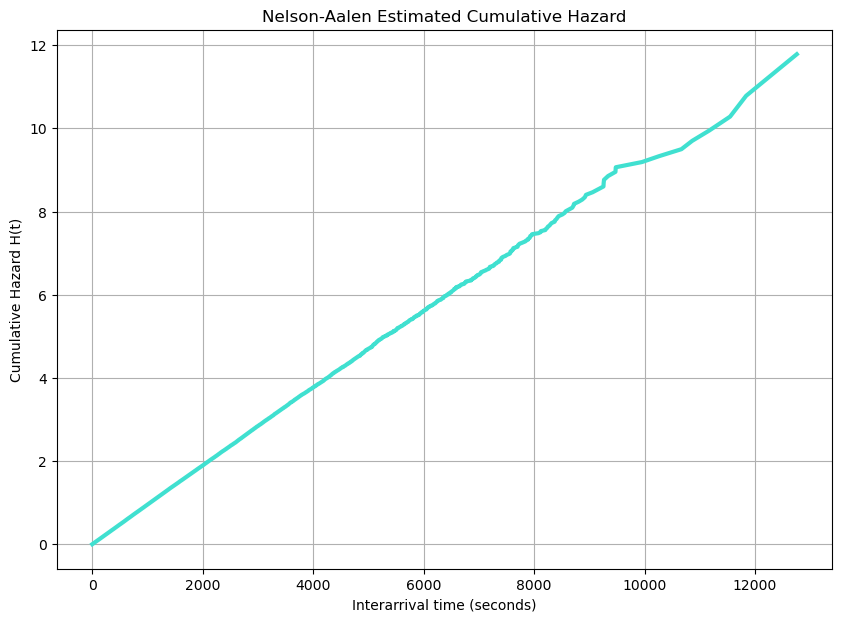

In [33]:
# Task 2 part 5 c

plt.figure(figsize=(10,7))
plt.plot(time_values, Ht, color='turquoise',linewidth='3')
plt.xlabel("Interarrival time (seconds)")
plt.ylabel("Cumulative Hazard H(t)")
plt.title("Nelson-Aalen Estimated Cumulative Hazard")
plt.grid(True, linestyle='-')

plt.show()

In [34]:
# the graph above is approximately linear, it increases at a linear rate and the cumulative hazard is predictable.
#  And since the slope is also constant the instantaneous failure rate can be viewed as constant

In [35]:
#5 d
#
# The system is in the normal life period of its cycle.
# This is seen by the flat section in the middle of the standard reliability curve.


In [36]:
# 5 e
# Estimate average hazard rate from the cumulative hazard rate
# assumption -> H(0) = 0 
max_T = time_values[-1] # last value from the array = final cumulative time
max_H = Ht[-1] # last value from the ascending array = final cumulative value
avg_Hrate = max_H / max_T

print("Max distinct t = " , max_T, "s")
print("cumulative hazard at max_T = " ,max_H)
print("Estimated average hazard rate = " ,avg_Hrate)

Max distinct t =  12756.961234331131 s
cumulative hazard at max_T =  11.78244000650439
Estimated average hazard rate =  0.0009236086705974977


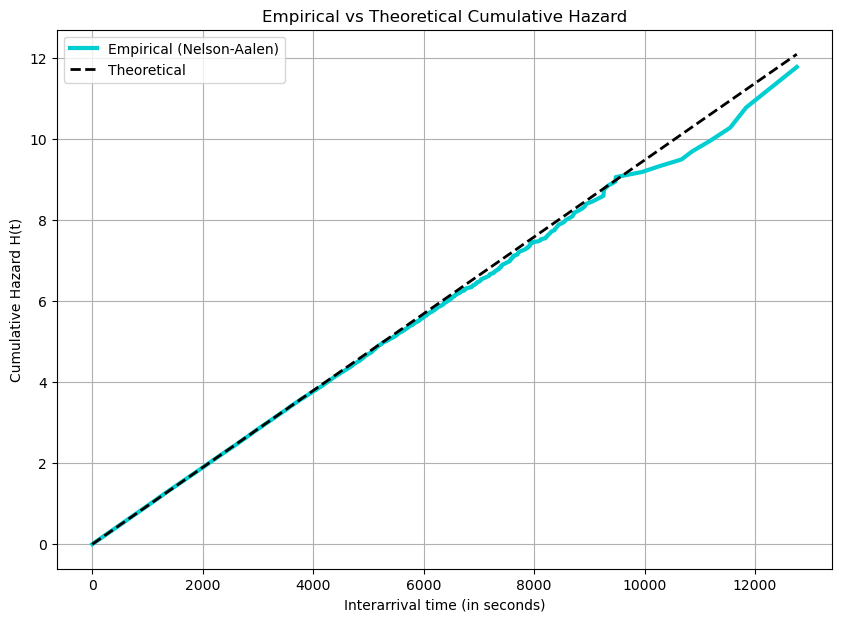

In [37]:
# 5 f
#
#
# The theoretical cumulative hazard function for an exponential distribution is:
# H(t) = lambda * t
# We already have the lambda in the lamb variable calculated previously part 1,2 of Task 2

Th_Ht = lamb * time_values
# plotting the T_Ht cumulative hazard function over the empirical Nelson-Aalen estimated function
plt.figure(figsize=(10,7))

#plot taken from 5 c
plt.plot(time_values, Ht, color='darkturquoise', linewidth=3, label='Empirical (Nelson-Aalen)')

# Theoretical plot
plt.plot(time_values, Th_Ht, color='black', linestyle='--', linewidth=2, label='Theoretical')

plt.xlabel("Interarrival time (in seconds)")
plt.ylabel("Cumulative Hazard H(t)")
plt.title("Empirical vs Theoretical Cumulative Hazard")
plt.grid(True, linestyle='-')
plt.legend()

plt.show()

In [38]:
# 5 g 
# As we can observe, the empirical Nelson-Aelen estimated cumulative hazard function and the theoretical cumulative hazard function represented with Th_Ht are pretty consistent
# We can see this as the dotted line covers the solid curve almost perfectly till about the first half of the graph.
# After which it follows the trend of the solid curve fairly well.
# Overall conclusion - Consistent with each other


In [39]:
#Task 3 starts here

In [40]:
import pandas as pd

#repeat steps in task 0 to flatten dataset and extract important information from the dataset
#data is noisy with duplicates

raw_noisy_dict = pd.read_pickle("delta_a100_gpu_xid_dataset_with_noise.pkl")
errors = []
for date, error_list in raw_noisy_dict.items():
   for i in error_list:
      i["Date"] = date
      errors.append(i)

df_noisy = pd.DataFrame(errors)
df_noisy = df_noisy[["Date", "datetime", "timestamp", "node_name", "device_id", "XID", "Tag"]]
df_noisy = df_noisy.sort_values(by='timestamp')

In [41]:
# 3.1a: Implement deduplication
anchors = {} # dictionary/ hash map of the most recent error for gpu.  key - gpu id, value - error row
good_idx = []
dup_idx = []

for idx, row in df_noisy.iterrows(): #extract each index and row data from the pandas dataframe one by one and do checks
    
    key = (row["node_name"], row["device_id"]) # check (i) only node name and device id have to match
    
    if key in anchors: # seen error
        anchor = anchors[key] # change the most recent to the newest one
        # Check if it meets criteria (ii)
        if (row["XID"] == anchor["XID"]) and ((row["timestamp"] - anchor["timestamp"]) <= 5):
            dup_idx.append(idx)
        else:
            anchors[key] = row # doesnt meet criteria so add it to valid idx
            good_idx.append(idx)
    if key not in anchors:
        anchors[key] = row # if error never seen, set it to the first seen one
        good_idx.append(idx)
    else:
        continue # in case of some garbage row with no value

df_dedup = df_noisy.loc[good_idx].copy()
df_duplicates = df_noisy.loc[dup_idx].copy()

total_idx = len(df_noisy)
total_duplicates = len(dup_idx)
dup_percent = (total_duplicates/total_idx) * 100
print("Percentage of duplicated XID entries: ", dup_percent,"%")


Percentage of duplicated XID entries:  13.484987890901785 %


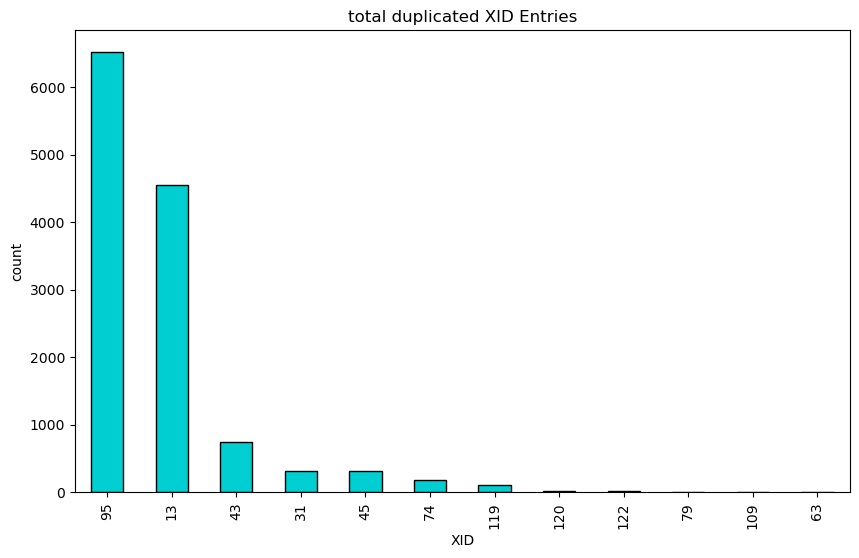

Top 5 duplicated XIDs:
XID 95 6520
XID 13 4558
XID 43 735
XID 31 313
XID 45 311
XID 74 179
Percentage accounted for by top 5: 98.94%


In [44]:
# 3.1b: Plot histogram of duplicate XID's
import matplotlib.pyplot as plt

dup_count = df_duplicates['XID'].value_counts() # use value_counts again (similar in task 1) takes each occurance of a  unique XID and counts how many times 
#it shows up
# essentially a faster, simplified hash map counting algorithm where key -> XID , value -> count

plt.figure(figsize=(10, 6))
plt.title("total duplicated XID Entries")
plt.xlabel("XID")
plt.ylabel("count")
plt.grid(axis='y', linestyle='-', alpha=0.6)
dup_count.plot(kind='bar', color='darkturquoise', edgecolor='black')

plt.show()

top_5 = {}
for i, (x,c) in enumerate(dup_count.items()):
    if i <= 5:
        top_5[x] = c
    else:
        break
print("Top 5 duplicated XIDs:")
top_5_sum = 0
for xid, count in top_5.items():
    top_5_sum += count
    print("XID", xid,  count)     
percent_top_5 = (top_5_sum/ len(df_duplicates)) * 100
print(f"Percentage accounted for by top 5: {percent_top_5:.2f}%")


In [45]:

# 3.1c: Remaining entries
good_entries = len(df_dedup)
print("Number of log entries remaining after deduplication: " , good_entries)


Number of log entries remaining after deduplication:  81806


In [46]:

# 3.1d: Compare top 5
top_5_whole_noisy_dataset = df_noisy["XID"].value_counts().head(5) # value_counts().head(5) gets first 5 sorted values desc order
print("Top 5 XIDs in noisy dataset:" , top_5_whole_noisy_dataset)

#after deduplication 
top_5_post_dedup = df_dedup["XID"].value_counts().head(5) 
print("Top 5 XIDs in deduplicated dataset:" , top_5_post_dedup)

Top 5 XIDs in noisy dataset: XID
13    59326
43    17329
95     6596
45     3913
31     3585
Name: count, dtype: int64
Top 5 XIDs in deduplicated dataset: XID
13    54768
43    16594
45     3602
31     3272
74     1922
Name: count, dtype: int64


In [47]:
window = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
num_dups = []

for w in window:  #similar to 3.1a , but this time we try to find the ideal window size and see if it makes a difference 
    #to do this just put 3.1a in a giant loop with a temp anchors_w and dup_count to find the optimal window size
    anchors_w = {}
    dup_count = 0
    for idx, row in df_noisy.iterrows():
        key = (row["node_name"],row["device_id"])
        if key in anchors_w:
            anchor = anchors_w[key]
            if (row["XID"] == anchor["XID"]) and ((row["timestamp"] - anchor["timestamp"]) <= w): #finding the right sized window
                dup_count += 1 #this time we just count and dont need to append anything to any list 
            else:
                anchors_w[key] = row
                continue
        if key not in anchors_w:
            anchors_w[key] = row
            
    num_dups.append(dup_count)


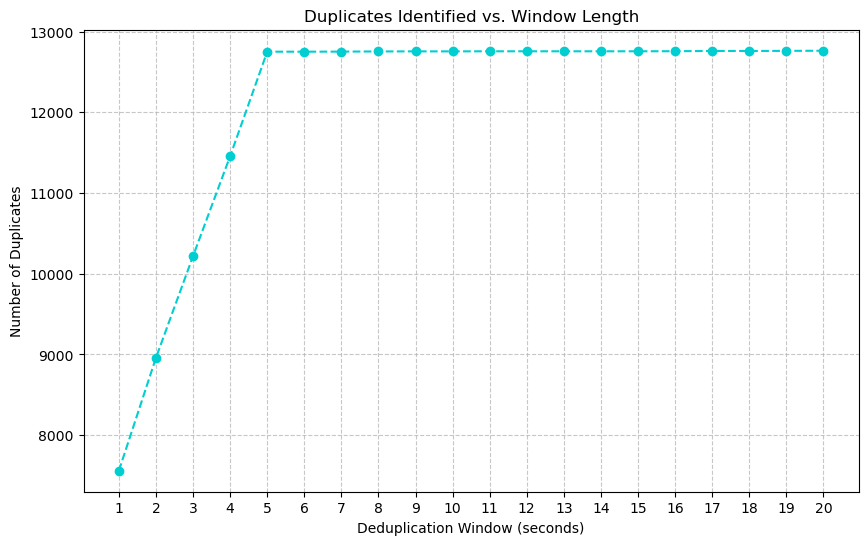

In [49]:

plt.figure(figsize=(10, 6))
plt.plot(window, num_dups, marker='o', color='darkturquoise', linestyle='--')
plt.title("Duplicates Identified vs. Window Length")
plt.xlabel("Deduplication Window (seconds)")
plt.ylabel("Number of Duplicates")
plt.xticks(window)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [50]:
# from this we see that any window size after 5s is the same for optimization, which means we should use 5 seconds as that would make computation much faster
# we have no need to compute extra 15 seconds worth of data per operation = huge time and compute save



In [51]:
# Task 3 part 3

df_dedup = df_dedup.sort_values(by=["node_name", "device_id", "timestamp"]) # have to sort by nodename and gpu if not would lead to uncoalesced pairs due to timestamp only
clsc_count = 0 # to count number of coalesced pairs
count_1343 = 0 # to count the XID 13->43
count_4313 = 0 # to count the XID 43->13

anchor = df_dedup.iloc[0] # start with the anchor being the 0th row
valid_idx = [0] # valid index array starts with the 0th row
for idx, row in df_dedup.iterrows():
    if idx ==0: #skipping 0th row cause thats our anchor
        continue
    if anchor["node_name"] == row["node_name"] and anchor["device_id"] == row["device_id"] and (row["timestamp"] - anchor["timestamp"])<=5 and ((anchor["XID"] == 13 and row["XID"] == 43) or (anchor["XID"] ==43 and row["XID"] == 13)):
        clsc_count += 1 # above are the conditions that need to be met for a coalesced pair
        if anchor["XID"] == 13: 
            count_1343 +=1
        else:
            count_4313 +=1
    else:
        anchor = row # updating anchor if we dont coalesce 
        valid_idx.append(idx)
df_clsc = df_dedup.loc[valid_idx].copy() # coalesced dataframe


print("The number of coalesced pairs are --- ",clsc_count)

print("The number of data entries left after coalescing are --- ", len(df_clsc))

print("Count for XID13 -> XID43 --- ", count_1343)

print("Count for XID43 -> XID13 --- ", count_4313)

# from this count we can be sure that XID 13 is more likely to be a cause whereas XID 43 is more likely to be a downstream symptom

The number of coalesced pairs are ---  8002
The number of data entries left after coalescing are ---  73804
Count for XID13 -> XID43 ---  8002
Count for XID43 -> XID13 ---  0


In [52]:
# Task 3 part 4
df_dedup = df_dedup.sort_values(by="timestamp") # need to resort because this relies on timestamp only
from collections import Counter
import statistics as stats

cluster_count = 1 # variable to point clusters for each row and also count total number of clusters
clusters = [cluster_count] # array to hold each rows cluster count, which basically is the cluster that it is part of
prev_row = df_dedup.iloc[0] # starting with the 0th row

for idx, row in df_dedup.iterrows():
    if idx == 0: # skipping 0th row cause we have it in prev
        continue
    if (row["timestamp"] - prev_row["timestamp"]) < 600:
        clusters.append(cluster_count) # if timediff is less than 600 seconds we append the row to the same cluster count
    else:
        cluster_count +=1 # else we make a new cluster
        clusters.append(cluster_count) # append that new cluster to the list
    prev_row = row # update the prev 


print("Total number of clusters are --- ", cluster_count)

cluster_lens = Counter(clusters) # creates a map with the count for each cluster
cluster_lens_vals = list(cluster_lens.values()) # make a list of the size of each cluster from the map to find its statistics
single_event = 0 # count for single event clusters
multi_event = 0 # count for multi event clusters

for val in cluster_lens_vals: # loop to count each value above
    if val == 1:
        single_event +=1
    else:
        multi_event +=1

print("Number of single event clusters --- ", single_event)
print("Number of multi event clustes ---", multi_event)

print("Fraction of single event clusters --- ", single_event/cluster_count)
print("Fraction of multi event clusters --- ", multi_event/cluster_count)
cluster_mean = stats.mean(cluster_lens_vals)
print("The mean cluster size is --- ", cluster_mean)

cluster_median = stats.median(cluster_lens_vals)
print("The median cluster size is --- ", cluster_median)

cluster_max = max(cluster_lens_vals)
print("The max cluster size is --- ", cluster_max)

cluster_std = stats.stdev(cluster_lens_vals)
print("The standard deviation for cluster size is --- ", cluster_std)

Total number of clusters are ---  41489
Number of single event clusters ---  20879
Number of multi event clustes --- 20610
Fraction of single event clusters ---  0.5032418231338427
Fraction of multi event clusters ---  0.4967581768661573
The mean cluster size is ---  1.9717515486032442
The median cluster size is ---  1
The max cluster size is ---  20
The standard deviation for cluster size is ---  1.3722155905862217


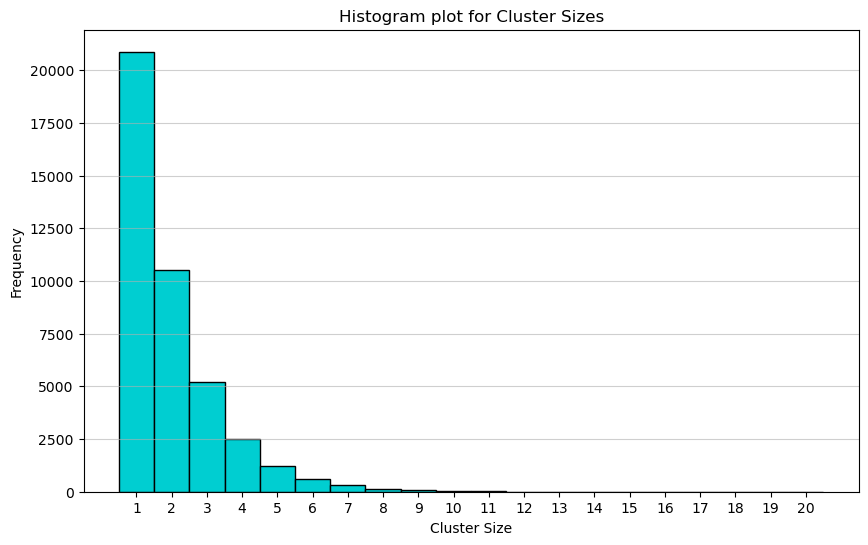

In [53]:
# Task 3 part 4 graphing cluster sizes 
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(cluster_lens_vals,bins=range(1,22), align='left', color = 'darkturquoise', edgecolor='black')
plt.title("Histogram plot for Cluster Sizes")
plt.xlabel("Cluster Size")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='-', alpha=0.6)
plt.xticks(range(1,21))
plt.show()


# The XID errors have very close to 50/50 chance of occuring in isolation or in clusters with others, if they do occur in clusters they are most likely a pair of 2 errors.

Cluster Duration Statistics (seconds):
  Mean:   210.59 s
  Median: 0.00 s
  Max:    3722.94 s
  Std:    351.58 s

Cluster Duration Statistics (hours):
  Mean:   0.0585 hr
  Median: 0.0000 hr
  Max:    1.0342 hr
  Std:    0.0977 hr


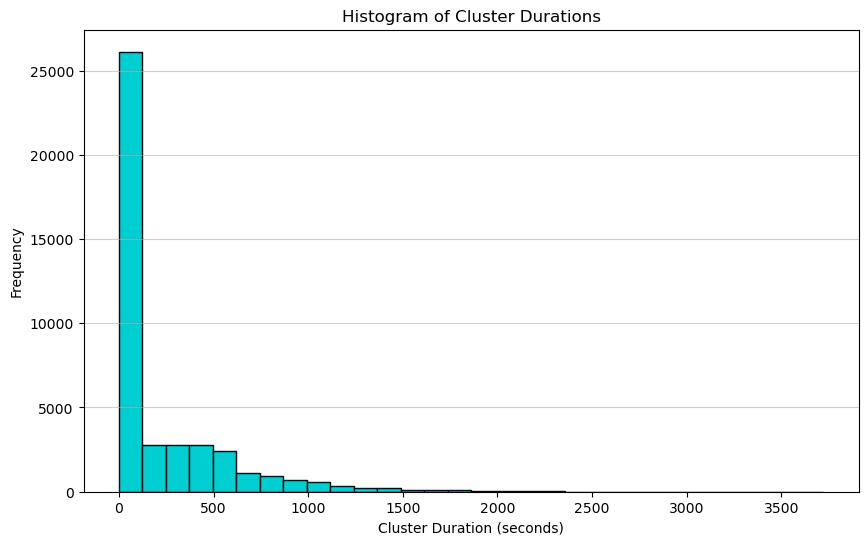

In [71]:
# Task 3 Part 4c: Cluster Duration Statistics

# Attach cluster labels to df_dedup so we can compute per-cluster durations
df_dedup_clustered = df_dedup.copy()
df_dedup_clustered['timestamp'] = df_dedup_clustered['timestamp'].astype(float)
df_dedup_clustered['cluster'] = clusters

# Duration = max timestamp - min timestamp within each cluster
cluster_durations_sec = (
    df_dedup_clustered.groupby('cluster')['timestamp']
    .apply(lambda x: x.max() - x.min())
)
cluster_durations_hr = cluster_durations_sec / 3600

print("Cluster Duration Statistics (seconds):")
print(f"  Mean:   {stats.mean(cluster_durations_sec):.2f} s")
print(f"  Median: {stats.median(cluster_durations_sec):.2f} s")
print(f"  Max:    {max(cluster_durations_sec):.2f} s")
print(f"  Std:    {stats.stdev(cluster_durations_sec):.2f} s")

print("\nCluster Duration Statistics (hours):")
print(f"  Mean:   {stats.mean(cluster_durations_hr):.4f} hr")
print(f"  Median: {stats.median(cluster_durations_hr):.4f} hr")
print(f"  Max:    {max(cluster_durations_hr):.4f} hr")
print(f"  Std:    {stats.stdev(cluster_durations_hr):.4f} hr")

plt.figure(figsize=(10, 6))
plt.hist(cluster_durations_sec, bins=30, color='darkturquoise', edgecolor='black')
plt.title("Histogram of Cluster Durations")
plt.xlabel("Cluster Duration (seconds)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='-', alpha=0.6)
plt.show()

# The distribution is heavily skewed toward 0 seconds, meaning most clusters 
# are very short-lived (bursty), where multiple XIDs fire in rapid succession.
# The long tail indicates a small number of clusters that persist for extended periods,
# suggesting occasional prolonged failure events but the dominant behavior is bursty.

In [72]:
# Task 3 Part 4d: Top 5 Most Common XID Combination Patterns in Multi-Event Clusters

# Group XIDs by cluster, keep only multi-event clusters
cluster_xid_sets = (
    df_dedup_clustered.groupby('cluster')['XID']
    .apply(lambda x: frozenset(x))  # order-less set of unique XIDs per cluster
)

# Filter to multi-event clusters only (more than 1 entry)
cluster_sizes = df_dedup_clustered.groupby('cluster').size()
multi_event_clusters = cluster_sizes[cluster_sizes > 1].index
multi_event_xid_sets = cluster_xid_sets[multi_event_clusters]

# Count frequency of each unique XID combination pattern
pattern_counts = Counter(multi_event_xid_sets)

print("Top 5 Most Common XID Combination Patterns in Multi-Event Clusters:")
for i, (pattern, count) in enumerate(pattern_counts.most_common(5)):
    xid_list = sorted(pattern)
    print(f"  #{i+1}: XIDs {xid_list}  —  {count} clusters")

Top 5 Most Common XID Combination Patterns in Multi-Event Clusters:
  #1: XIDs [13, 43]  —  8771 clusters
  #2: XIDs [13]  —  5596 clusters
  #3: XIDs [13, 45]  —  1052 clusters
  #4: XIDs [13, 31]  —  1009 clusters
  #5: XIDs [13, 43, 45]  —  654 clusters


In [69]:
# Task 3 part 5 a
# We use df_clsc, the most processed version of the dataset so far for this part
# Sort globally by timestamp for the propagation analysis

df_prop = df_clsc.copy()
df_prop['timestamp'] = df_prop['timestamp'].astype(float)  # ensure numeric
df_prop = df_prop.sort_values(by='timestamp').reset_index(drop=True)

# The sample space of V is the set of all XIDs that could follow XID A,
# plus None for the case where XID A is an isolated error (no successor within 600s).
# so the number of unique XIDs plus none for the case where no error occurs is the sample space
unique_xids = sorted(df_prop['XID'].unique())
sample_space = unique_xids + [None]

print("Task 3 Part 5a:")
print(f"Unique XIDs in dataset: {unique_xids}")
print(f"\nSample space of V = (all unique XIDs) ∪ {{None}} for isolated errors")
print(f"Sample space size: {len(sample_space)}  ({len(unique_xids)} XIDs + None)")

Task 3 Part 5a:
Unique XIDs in dataset: [np.int64(13), np.int64(31), np.int64(43), np.int64(45), np.int64(63), np.int64(74), np.int64(79), np.int64(94), np.int64(95), np.int64(109), np.int64(119), np.int64(120), np.int64(122)]

Sample space of V = (all unique XIDs) ∪ {None} for isolated errors
Sample space size: 14  (13 XIDs + None)


Task 3 Part 5b – System-Level Propagation Probability Matrix:
           13        31        43        45        63        74        79        94        95       109       119       120       122      None
13   0.325628  0.018989  0.050906  0.020359  0.000037  0.011120  0.000018  0.000018  0.000420  0.000237  0.008271  0.000803  0.000274  0.562920
31   0.312042  0.020171  0.054707  0.018337  0.000611  0.014364  0.000000  0.000000  0.000000  0.000000  0.005501  0.000611  0.000611  0.573044
43   0.329143  0.018622  0.051909  0.022114  0.000000  0.012686  0.000000  0.000233  0.000466  0.000233  0.005819  0.000815  0.000349  0.557612
45   0.318712  0.022210  0.053859  0.023598  0.000000  0.011938  0.000000  0.000000  0.000278  0.000000  0.009994  0.000278  0.000555  0.558579
63   0.600000  0.100000  0.000000  0.000000  0.000000  0.100000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.200000
74   0.348595  0.020812  0.049948  0.018730  0.000000  0.010406  0.000000 

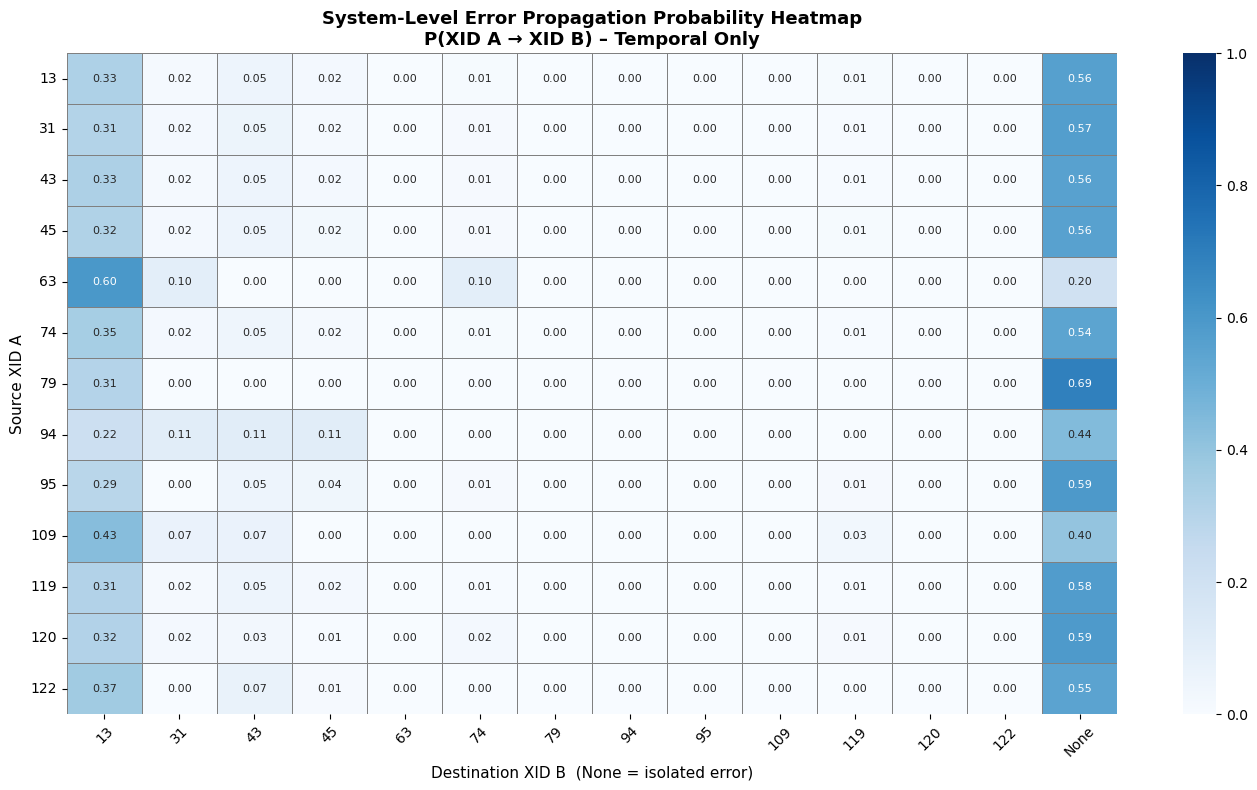

In [70]:
# Task 3 Part 5b: System-level error propagation analysis
# (temporal-only: consecutive XIDs regardless of node or device)
from collections import defaultdict
import seaborn as sns

# writing code as functions so can be reused for 5d
def build_propagation_matrix(df, window=600, level='system'):
    all_xids = sorted(df['XID'].unique())
    col_labels = [str(x) for x in all_xids] + ['None']

    # Count matrix: trans_counts[xid_a][xid_b_str] = count
    trans_counts = defaultdict(lambda: defaultdict(int))

    if level == 'system':
        # One global sorted sequence
        records = df[['timestamp', 'XID']].values  # numpy array for speed
        for i in range(len(records)):
            xid_a = records[i, 1]
            if i + 1 < len(records):
                time_diff = records[i + 1, 0] - records[i, 0]
                xid_b_str = str(int(records[i + 1, 1])) if time_diff <= window else 'None'
            else:
                xid_b_str = 'None'  # last entry is always isolated
            trans_counts[xid_a][xid_b_str] += 1

    elif level == 'device':
        # Separate sequence per (node_name, device_id)
        for (node, dev), grp in df.groupby(['node_name', 'device_id']):
            grp = grp.sort_values('timestamp')
            records = grp[['timestamp', 'XID']].values
            for i in range(len(records)):
                xid_a = records[i, 1]
                if i + 1 < len(records):
                    time_diff = records[i + 1, 0] - records[i, 0]
                    xid_b_str = str(int(records[i + 1, 1])) if time_diff <= window else 'None'
                else:
                    xid_b_str = 'None'
                trans_counts[xid_a][xid_b_str] += 1

    # Build probability and count DataFrames
    prob_rows = []
    count_rows = []
    row_labels = []
    for xid_a in all_xids:
        if xid_a not in trans_counts:
            continue
        total = sum(trans_counts[xid_a].values())
        prob_row  = [trans_counts[xid_a].get(c, 0) / total  for c in col_labels]
        count_row = [trans_counts[xid_a].get(c, 0)          for c in col_labels]
        prob_rows.append(prob_row)
        count_rows.append(count_row)
        row_labels.append(xid_a)

    prob_df  = pd.DataFrame(prob_rows,  index=row_labels, columns=col_labels)
    counts_df = pd.DataFrame(count_rows, index=row_labels, columns=col_labels)
    return prob_df, counts_df

# Plot a probability heatmap for propagation analysis
def plot_heatmap(prob_df, title):
    
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(
        prob_df,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.4,
        linecolor='grey',
        vmin=0, vmax=1,
        ax=ax,
        annot_kws={'size': 8}
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Destination XID B  (None = isolated error)', fontsize=11)
    ax.set_ylabel('Source XID A', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.show()


# Build and plot system-level heatmap
prob_sys, counts_sys = build_propagation_matrix(df_prop, window=600, level='system')

print("Task 3 Part 5b – System-Level Propagation Probability Matrix:")
print(prob_sys.to_string())
print()
plot_heatmap(prob_sys, 'System-Level Error Propagation Probability Heatmap\nP(XID A → XID B) – Temporal Only')

In [62]:
# Task 3 Part 5c
# Probability axiom: each row is a valid probability distribution, so every row must SUM TO 1 
print("Task 3 Part 5c – Row Sum Verification (each row must sum to 1.0):")
row_sums = prob_sys.sum(axis=1)
print(row_sums.to_string())

print("\nMost probable next event for each Source XID A (system-level):")
for xid_a, row in prob_sys.iterrows():
    best_dest = row.idxmax()
    best_prob = row.max()
    print(f"  XID {xid_a:>3}  →  {best_dest:<6}  (P = {best_prob:.4f})")

Task 3 Part 5c – Row Sum Verification (each row must sum to 1.0):
13     1.0
31     1.0
43     1.0
45     1.0
63     1.0
74     1.0
79     1.0
94     1.0
95     1.0
109    1.0
119    1.0
120    1.0
122    1.0

Most probable next event for each Source XID A (system-level):
  XID  13  →  None    (P = 0.5629)
  XID  31  →  None    (P = 0.5730)
  XID  43  →  None    (P = 0.5576)
  XID  45  →  None    (P = 0.5586)
  XID  63  →  13      (P = 0.6000)
  XID  74  →  None    (P = 0.5432)
  XID  79  →  None    (P = 0.6923)
  XID  94  →  None    (P = 0.4444)
  XID  95  →  None    (P = 0.5921)
  XID 109  →  13      (P = 0.4333)
  XID 119  →  None    (P = 0.5787)
  XID 120  →  None    (P = 0.5882)
  XID 122  →  None    (P = 0.5493)


Task 3 Part 5d – Device-Level Propagation Probability Matrix:
           13        31        43        45   63        74   79   94   95  109       119  120  122      None
13   0.018021  0.000292  0.000566  0.000091  0.0  0.000073  0.0  0.0  0.0  0.0  0.000201  0.0  0.0  0.980755
31   0.005196  0.000000  0.000306  0.000306  0.0  0.000000  0.0  0.0  0.0  0.0  0.000306  0.0  0.0  0.993888
43   0.002677  0.000349  0.000000  0.000000  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.996974
45   0.003054  0.000000  0.000000  0.000000  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.996946
63   0.000000  0.000000  0.000000  0.000000  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  1.000000
74   0.002081  0.000000  0.000000  0.000000  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.997919
79   0.076923  0.000000  0.000000  0.000000  0.0  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.923077
94   0.000000  0.000000  0.000000  0.000000  0.0  0.000000  0.0  0

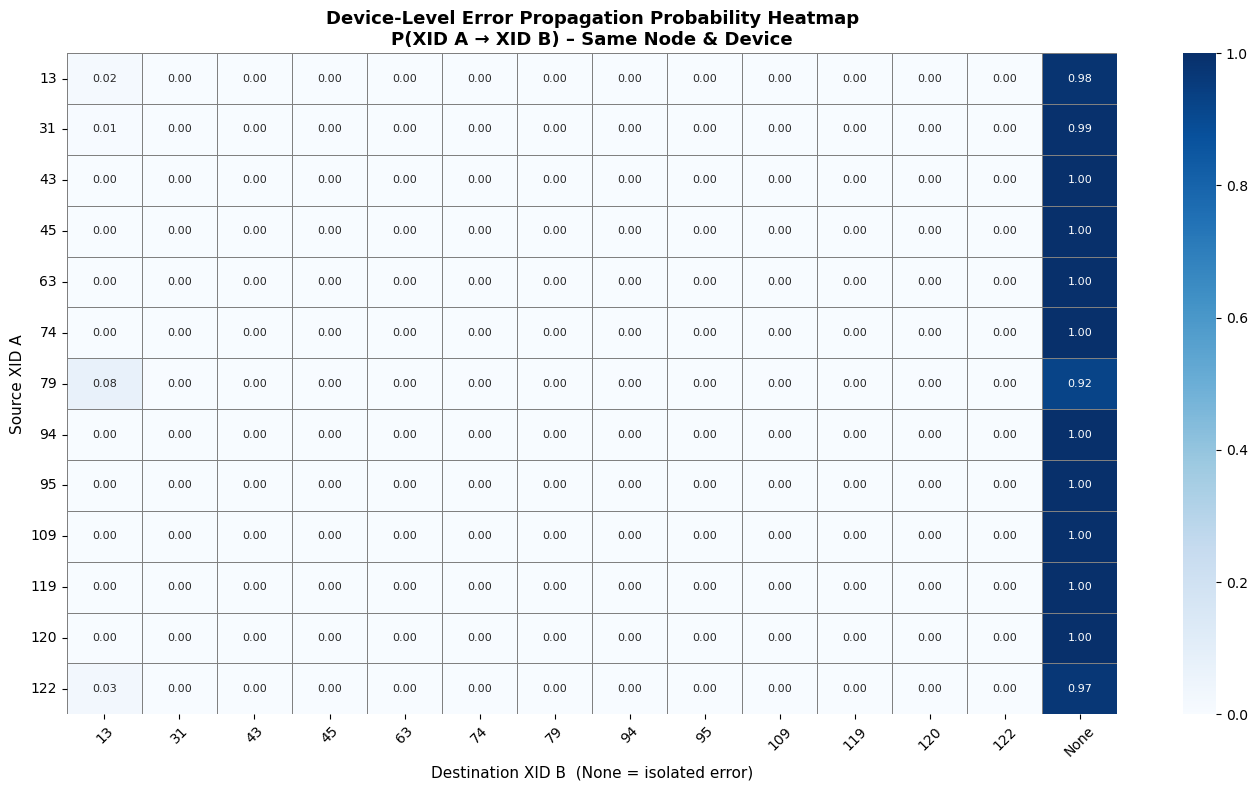

In [67]:
# Task 3 Part 5d – Device-level propagation analysis
# XID A and XID B must come from the same GPU device on the same node.
# repeat part 5b with functions previously defined:

prob_dev, counts_dev = build_propagation_matrix(df_prop, window=600, level='device')

print("Task 3 Part 5d – Device-Level Propagation Probability Matrix:")
print(prob_dev.to_string())
print()
plot_heatmap(prob_dev, 'Device-Level Error Propagation Probability Heatmap\nP(XID A → XID B) – Same Node & Device')

In [64]:
# Task 3 Part 5e – Compare system-level vs. device-level propagation

print("Task 3 Part 5e – Comparison of System-Level vs. Device-Level Propagation\n")

# Show the 'None' column (isolation probability) side by side
isolation_sys = prob_sys['None'].rename('System-level P(Isolated)')
isolation_dev = prob_dev['None'].rename('Device-level P(Isolated)')
comparison = pd.concat([isolation_sys, isolation_dev], axis=1)
print("Isolation probability P(XID A → None) per level:")
print(comparison.to_string())

Task 3 Part 5e – Comparison of System-Level vs. Device-Level Propagation

Isolation probability P(XID A → None) per level:
     System-level P(Isolated)  Device-level P(Isolated)
13                   0.562920                  0.980755
31                   0.573044                  0.993888
43                   0.557612                  0.996974
45                   0.558579                  0.996946
63                   0.200000                  1.000000
74                   0.543184                  0.997919
79                   0.692308                  0.923077
94                   0.444444                  1.000000
95                   0.592105                  1.000000
109                  0.400000                  1.000000
119                  0.578665                  0.996930
120                  0.588235                  1.000000
122                  0.549296                  0.971831


In [42]:
# Task 4 starts here
# Part 1

# Null Hypothesis (H0): The GPU device is operating normally; its state is unchanged, and there is no imminent failure.
# Alternative Hypothesis (H1): The GPU device is in an undesirable/alternative state, indicating an imminent failure.



In [58]:

# Task 4 Part 1.2 - ML and MAP Rules
import pandas as pd

# Load the CSV
df_labeled = pd.read_csv("delta_a100_gpu_xid_dataset_with_GPU_failure_label.csv")

# print all the columns of the new dataset to see what we are dealing with
# print("The columns in this dataset are:") 
# print(df_labeled.columns.tolist())


target_col = "GPU_failed"
target_xids = [119, 95, 13, 45, 94, 31]

# calculate the priors 
total_h1 = len(df_labeled[df_labeled["GPU_failed"] == 1]) # H1 - failures
total_h0 = len(df_labeled[df_labeled["GPU_failed"] == 0]) # H0 - successes

print("ML Rule Guess")
print("XID   |  P(X|H0)   | P(X|H1)    | ML Prediction")
print("-------------------------------------------------")

for x in target_xids:
    count_x_h1 = len(df_labeled[(df_labeled['XID'] == x) & (df_labeled[target_col] == 1)])
    count_x_h0 = len(df_labeled[(df_labeled['XID'] == x) & (df_labeled[target_col] == 0)])
    
    p_x_given_h1 = count_x_h1 / total_h1 
    p_x_given_h0 = count_x_h0 / total_h0 
    
    # Maximize P(X|Y)
     
    if p_x_given_h1 > p_x_given_h0:
        ml_pred = "H1"
    else:
        ml_pred = "H0"
    
    print(f"{x:<5} | {round(p_x_given_h0,4)}     | {round(p_x_given_h1,5)}    | {ml_pred}")

ML Rule Guess
XID   |  P(X|H0)   | P(X|H1)    | ML Prediction
-------------------------------------------------
119   | 0.0016     | 0.22044    | H1
95    | 0.0003     | 0.01024    | H1
13    | 0.7026     | 0.19885    | H0
45    | 0.0436     | 0.05083    | H1
94    | 0.0001     | 0.0    | H0
31    | 0.0331     | 0.13759    | H1


## Task 4 part 1.3
Data Sufficiency: Yes, the provided dataset is sufficient. The prior probabilities $P(H_0)$ and $P(H_1)$ can be directly calculated using the empirical counts of the binary labels in the dataset.Difference: The ML rule maximizes only the likelihood $P(X|Y)$, assuming all outcomes are equally probable. The MAP rule maximizes the posterior probability ($P(X|Y) \times P(Y)$), which explicitly factors in the baseline prior probability of each outcome occurring.Preference: The MAP rule is preferable for failure events. Because actual GPU failures are rare, the prior probability of a failure ($P(H_1)$) is extremely small. The MAP rule mathematically accounts for this rarity, preventing the excessive false positive predictions that the ML rule would trigger.


In [1]:
# Task 4 part 1.4
p_h1 = total_h1 / total_obs
p_h0 = total_h0 / total_obs

print("MAP Rule Guess")
print("priors : P(H0) =", round(p_h0,5) , "P(H1) =", round(p_h1,5))
print(f"{'XID'}   | {'P(X|H0)*P(H0)'}   | {'P(X|H1)*P(H1)'}   | {"MAP Guess"}")
print("------------------------------------------------------------------------------------")

for x in target_xids:
    count_x_h1 = len(df_labeled[(df_labeled['XID'] == x) & (df_labeled[target_col] == 1)])
    count_x_h0 = len(df_labeled[(df_labeled['XID'] == x) & (df_labeled[target_col] == 0)])
    
    p_x_given_h1 = count_x_h1 / total_h1
    p_x_given_h0 = count_x_h0 / total_h0
    
    # MAP Rule Logic: Maximize P(X|Y) * P(Y)
    map_h1 = p_x_given_h1 * p_h1
    map_h0 = p_x_given_h0 * p_h0
    
    if map_h1 > map_h0:
        map_pred = "H1" 
    else:
        map_pred = "H0"
    
    print(f"{x:4}      {round(map_h0,5):5}           {round(map_h1,5):10}             {map_pred}")

NameError: name 'total_h1' is not defined

## 6 e
Naive Bayes MAP Decision Rule Formula:Using the example cluster $X = \{119, 120, 79, 13\}$, the MAP decision rule to classify the cluster is:
$$\hat{Y}_{MAP} = \arg\max_{y \in \{0, 1\}} \left[ P(Y=y) \cdot P(X_{119}=1|y) \cdot P(X_{120}=1|y) \cdot P(X_{79}=1|y) \cdot P(X_{13}=1|y) \cdot \prod_{j \notin \{119, 120, 79, 13\}} P(X_j=0|y) \right]$$

